In [70]:
from matplotlib import pyplot as plt
from matplotlib.patches import Circle
import skimage
import numpy as np
import imageio.v3 as iio
from ipywidgets import interact, IntSlider

In [63]:
focal = 485.82423388827533     # focal length (f)
centerx = 134.875              # principal point x (cx)
centery = 239.875              # principal point y (cy)
ball_radius = 3                # ball radius in centimeters (R)
video_path = 'videos/red.mov'  # path to video

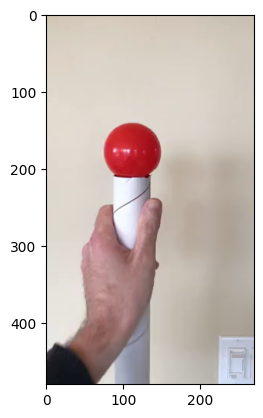

In [64]:
frames = [frame for frame in iio.imiter(video_path)] # load all frames of video
plt.imshow(frames[0]) # show first frame

In [97]:
def preprocess_image(image):
    """ Convert image to grayscale and run Canny edge detector.
        Arguments:
            image: RGB image
        Returns:
            Result of Canny edge detector
    """
    gray = skimage.color.rgb2gray(image)
    return skimage.feature.canny(gray)

In [96]:
def detect_circles(edges):
    """ Detect circles in image.
        Arguments:
            edges: edge image produced by preprocess_image()
        Returns:
            List of tuples (x, y, radius)
    """
    potential_radius = np.arange(15, 200, 2)
    hough = skimage.transform.hough_circle(edges, potential_radius)
    accums, cx, cy, detected_radii = skimage.transform.hough_circle_peaks(
        hough, potential_radius, total_num_peaks=1
    )
    return list(zip(cx, cy, detected_radii))

In [98]:
def calculate_ball_position(x,y,r):
    """ Calculate ball's (X,Y,Z) position in world coordinates
        Arguments:
            x,y: 2D position of ball in image
            r: radius of ball in image
        Returns:
            X,Y,Z position of ball in world coordinates
    """
    Z_estimated = (focal * ball_radius) / r
    X = (x - centerx) * Z_estimated / focal
    Y = (y - centery) * Z_estimated / focal
    return X, Y, Z_estimated

In [88]:
def draw_ball(x,y,r,Z):
    """ Draw circle on ball and write depth estimate in center
        Arguments:
            x,y,r: 2D position and radius of ball
            Z: estimated depth of ball
    """
    ax = plt.gca()
    ax.add_patch(
        Circle((x, y), r, fill=False, edgecolor="lime", linewidth=2)
    )
    ax.text(
        x, y, f"{Z:.1f} cm",
        color="black",
        ha="center",
        va="center",
    )
    return

In [72]:
def project(X,Y,Z):
    """ Pinhole projection.
        Arguments:
            X,Y,Z: 3D point
        Returns:    
            (x,y) 2D location of projection in image
    """
    x = (X * focal) / Z + centerx
    y = (Y * focal) / Z + centery
    return x, y

In [73]:
def draw_line_2d(x1,y1,x2,y2):
    """ Draw a 2D line
        Arguments:
            x1,y1: 2D position of first line endpoint
            x2,y2: 2D position of second line endpoint
    """
    plt.plot(
        [x1, x2],  # x-coordinates
        [y1, y2],  # y-coordinates
        color="black",
        linewidth=2
    )
    return

In [92]:
def draw_line_3d(X1,Y1,Z1,X2,Y2,Z2):
    """ Draw a 3D line.  (This should call draw_line_2d.)
        Arguments:
            X1,Y1,Z1: 3D position of first line endpoint
            X2,Y2,Z2: 3D position of second line endpoint
    """
    x1, y1 = project(X1, Y1, Z1)
    x2, y2 = project(X2, Y2, Z2)
    draw_line_2d(x1, y1, x2, y2)
    return

In [93]:
def draw_bounding_cube(X,Y,Z):
    """ Draw bounding cube around 3D point, with radius R
        Arguments:
            image: image on which to draw
            X,Y,Z: 3D center point of cube
    """
    # front face
    draw_line_3d(X+ball_radius, Y+ball_radius, Z+ball_radius, X+ball_radius, Y-ball_radius, Z+ball_radius) # FTR to FBR
    draw_line_3d(X+ball_radius, Y-ball_radius, Z+ball_radius, X-ball_radius, Y-ball_radius, Z+ball_radius) # FBR to FBL
    draw_line_3d(X-ball_radius, Y-ball_radius, Z+ball_radius, X-ball_radius, Y+ball_radius, Z+ball_radius) # FBL to FTL
    draw_line_3d(X-ball_radius, Y+ball_radius, Z+ball_radius, X+ball_radius, Y+ball_radius, Z+ball_radius) # FTL to FTR
    # back face
    draw_line_3d(X+ball_radius, Y+ball_radius, Z-ball_radius, X+ball_radius, Y-ball_radius, Z-ball_radius) # BTR to BBR
    draw_line_3d(X+ball_radius, Y-ball_radius, Z-ball_radius, X-ball_radius, Y-ball_radius, Z-ball_radius) # BBR to BBL
    draw_line_3d(X-ball_radius, Y-ball_radius, Z-ball_radius, X-ball_radius, Y+ball_radius, Z-ball_radius) # BBL to BTL
    draw_line_3d(X-ball_radius, Y+ball_radius, Z-ball_radius, X+ball_radius, Y+ball_radius, Z-ball_radius) # BTL to BTR
    # connecting edges
    draw_line_3d(X+ball_radius, Y+ball_radius, Z+ball_radius, X+ball_radius, Y+ball_radius, Z-ball_radius) # FTR to BTR
    draw_line_3d(X+ball_radius, Y-ball_radius, Z+ball_radius, X+ball_radius, Y-ball_radius, Z-ball_radius) # FBR to BBR
    draw_line_3d(X-ball_radius, Y-ball_radius, Z+ball_radius, X-ball_radius, Y-ball_radius, Z-ball_radius) # FBL to BBL
    draw_line_3d(X-ball_radius, Y+ball_radius, Z+ball_radius, X-ball_radius, Y+ball_radius, Z-ball_radius) # FTL to BTL
    return

In [77]:
def preprocess_frame(i):
    plt.imshow(preprocess_image(frames[i]))

In [79]:
def find_ball_in_frame(i):
    plt.imshow(frames[i])
    preprocessed_frame = preprocess_image(frames[i])
    circles = detect_circles(preprocessed_frame)
    for circle in circles:
        x, y, r = circle
        X, Y, Z = calculate_ball_position(x, y, r)
        draw_ball(x, y, r, Z)
    plt.show()

In [90]:
def process_cube_frame(i):
    plt.imshow(frames[i])
    preprocessed_frame = preprocess_image(frames[i])
    circles = detect_circles(preprocessed_frame)
    for circle in circles:
        x, y, r = circle
        X, Y, Z = calculate_ball_position(x, y, r)
        draw_bounding_cube(X, Y, Z)
    plt.show()

In [94]:
# example of interactive video display
def process_frame(i):
    plt.imshow(frames[i])
    
interact(preprocess_frame, i=IntSlider(min=0, max=len(frames)-1, step=1, value=0))
interact(find_ball_in_frame, i=IntSlider(min=0, max=len(frames)-1, step=1, value=0))
interact(process_cube_frame, i=IntSlider(min=0, max=len(frames)-1, step=1, value=0))

interactive(children=(IntSlider(value=0, description='i', max=116), Output()), _dom_classes=('widget-interact'…

interactive(children=(IntSlider(value=0, description='i', max=116), Output()), _dom_classes=('widget-interact'…

interactive(children=(IntSlider(value=0, description='i', max=116), Output()), _dom_classes=('widget-interact'…

<function __main__.process_cube_frame(i)>

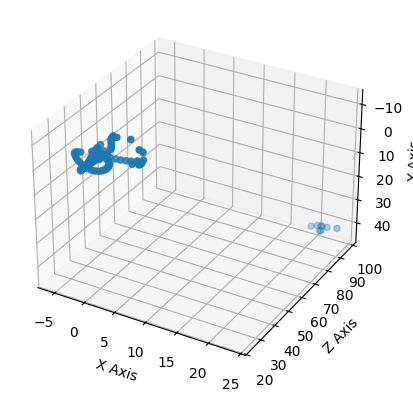

In [103]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
xs = []
ys = []
zs = []

for frame in frames:
    preprocessed_frame = preprocess_image(frame)
    circles = detect_circles(preprocessed_frame)
    for circle in circles:
        x, y, r = circle
        X, Y, Z = calculate_ball_position(x, y, r)
        xs.append(X)
        ys.append(Y)
        zs.append(Z)

ax.scatter(xs, zs, ys)
ax.invert_zaxis()

ax.set_xlabel('X Axis')
ax.set_ylabel('Z Axis')
ax.set_zlabel('Y Axis')

plt.show()